# Problem 1

Make a figure of the sin/cos functions using 100 equally spaced samples in the interval \[0:2pi\]

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

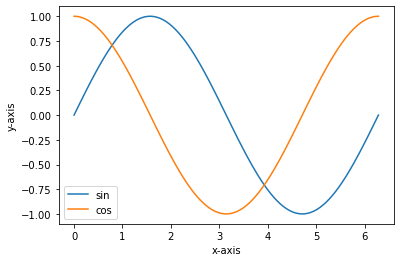

In [25]:
x = np.linspace(0,2*np.pi,100)
y1 = np.sin(x)
y2 = np.cos(x)
f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.plot(x,y1,label="sin")
ax.plot(x,y2,label="cos")

plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.legend()

plt.show()

Make a figure with 2 rows showing the plots of sin/cos in the interval \[0:2pi\]

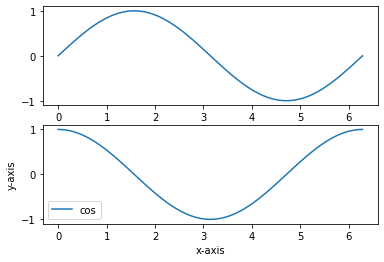

In [28]:
x = np.linspace(0,2*np.pi,100)
y1 = np.sin(x)
y2 = np.cos(x)
fig, axis = plt.subplots(2)
axis[0].plot(x,y1,label="sin")
axis[1].plot(x,y2,label="cos")

plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.legend()

plt.savefig('1.png')

Make a plot of the logarithmic function in the interval \[1e-5,1e1\] using logscale for the x-axis. Calculate the function over 10 samples equally spaced in the logarithmic scale (np.logspace). Hint: check the xscale method of plt, or the set_xscale method of axis objects.

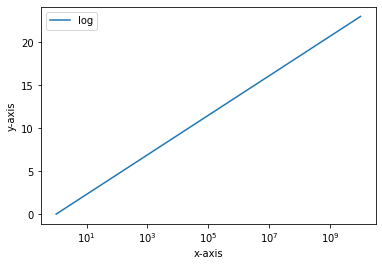

In [31]:
x = np.logspace(1e-5,1e1,num=10)
y1 = np.log(x)
f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.plot(x,y1,label="log")
ax.set_xscale('log')
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.legend()

plt.savefig('1.png')

# Problem 2
The file ex9_1.txt includes data for a set of patients. The data are organized into rows with the following format: *x time sex*, where x is an experimental measurement, time is when the measurement was taken (in seconds), and sex is 0 for male and 1 for female.

Use the method np.genfromtxt to import the data from the file into a numpy array.

Make a plot of x versus time for all the samples, using dots as markers.

The time variable is clustered around 4 time points, being approximatively 6 hours, 12 hours, 24 hours, and 48 hours. Make a plot using errorbars where all the samples belonging to a particular time interval (close to 6 hours, close to 12 hours, etc...) are used to calculate the average values and standard deviations for that group of data, both for time and x variable.

Add on the top of the previous plot the individual samples, using different colors for males and females (use scatter). 

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
data_set=np.genfromtxt("./ex09_1.txt",delimiter=" ",dtype=float)
print(data_set)

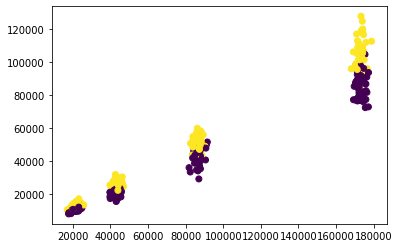

In [49]:
x = data_set[:,1]
y = data_set[:,0]
f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.scatter(x,y, marker = 'o',c=data_set[:,2])
plt.show()

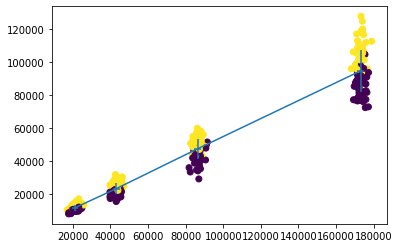

In [50]:
time_points = 3600*np.array([6,12,24,48])
time_mean = np.empty(len(time_points))
x_mean = np.empty(len(time_points))
time_std = np.empty(len(time_points))
x_std = np.empty(len(time_points))
accessing = np.abs(data_set[:,1] - time_points.reshape(-1,1)).argmin(axis = 0)
for i,time in enumerate(time_points):
    x_mean[i] = np.mean(data_set[accessing == i,0])
    x_std[i] = np.std(data_set[accessing == i,0])
    time_mean[i] = np.mean(data_set[accessing == i,1])
    time_std[i]= np.std(data_set[accessing == i,1])
f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.errorbar(time_mean,x_mean,xerr=time_std,yerr=x_std)
ax.scatter(x,y, marker = 'o',c=data_set[:,2])
plt.show()

# Problem 3
Using the same data of the previous exercise, make a plot with 4 panels, where each panel show the histogram of x for samples close to 6, 12, 24 and 48 hours, separately for men and women.

In [ ]:
%matplotlib notebook
import matplotlib.pyplot as plt
import numpy as np

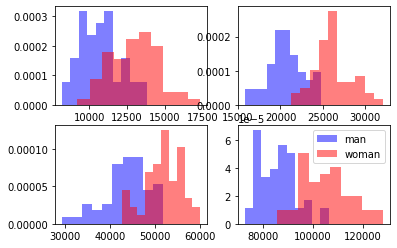

In [64]:
 f = plt.figure()
time_points = 3600*np.array([6,12,24,48])
inds = np.abs(data_set[:,1] - time_points.reshape(-1,1)).argmin(axis = 0)
for i, time in enumerate(time_points):
    ax = f.add_subplot(2,2,i+1)
    men = data_set[(inds == i) & (data_set[:,2] == 0),0]
    ax.hist(men,bins=10,color="blue",density=True,stacked=True,label="man",alpha=0.5)
    women = data_set[(inds == i) & (data_set[:,2] == 1),0]
    ax.hist(women,bins=10,color="red",density=True,stacked=True,label="woman",alpha=0.5)
plt.legend(loc='upper right')
plt.show()

# Problem 4
The file ex9_2.txt includes data for an energy map in 2-dimensions. The file is organized into lines with format: *x, y, energy*. The lines are ordered with the y values increasing the fastest.

Example:
 
 \[...\]
 
 -15.875 -15.875  5.65432
 
 -15.875 -15.625  5.36195
 
 -15.875 -15.375  5.40075
 
 -15.875 -15.125  4.90258
 
 \[...\]

The 2-dimensional data are organized into a square grid with shape 152 x 152.

Import the data using np.genfromtxt, and use the np.reshape method to create 2-dimensional arrays with shape 152 x 152.

Make a contour plot of the energy as a function of x and y.

In [ ]:
%matplotlib notebook
import matplotlib.pyplot as plt
import numpy as np

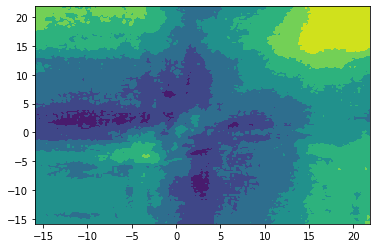

In [72]:
data_set = np.genfromtxt("ex09_2.txt",delimiter=" ",dtype=float,skip_header=4)
cleaned_data_set = data_set[:,[0,1,3]]
X = cleaned_data_set[:,0].reshape((152,152))
Y = cleaned_data_set[:,1].reshape((152,152))
A = cleaned_data_set[:,2].reshape((152,152))

f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.contourf(X,Y,A)